#  Previsão de Preço de Imóveis — São Paulo

Objetivo: entender a distribuição dos dados, identificar padrões de preço por bairro, tratar valores ausentes e preparar o dataset para modelagem.

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Bibliotecas carregadas com sucesso')

Bibliotecas carregadas com sucesso


## 2. Carregando os dados

In [2]:
df = pd.read_csv('../data/data.csv')

print(f'Shape: {df.shape}')
print(f'Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}')
df.head()


Shape: (11657, 8)
Linhas: 11,657 | Colunas: 8


,address,district,area,bedrooms,garage,type,rent,total
0,Rua Herval,Belenzinho,21,1,0,Studio e kitnet,2400,2939
1,Avenida São Miguel,Vila Marieta,15,1,1,Studio e kitnet,1030,1345
2,Rua Oscar Freire,Pinheiros,18,1,0,Apartamento,4000,4661
3,Rua Júlio Sayago,Vila Ré,56,2,2,Casa em condomínio,1750,1954
4,Rua Barata Ribeiro,Bela Vista,19,1,0,Studio e kitnet,4000,4654


## 3. Visão geral do dataset

In [3]:
print('=== TIPOS DAS COLUNAS ===')
print(df.dtypes)
print()
print('=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe()

=== TIPOS DAS COLUNAS ===
address     object
district    object
area         int64
bedrooms     int64
garage       int64
type        object
rent         int64
total        int64
dtype: object

=== ESTATÍSTICAS DESCRITIVAS ===


,area,bedrooms,garage,rent,total
count,11657.000000,11657.000000,11657.000000,11657.000000,11657.000000
mean,84.655658,1.966286,1.060393,3250.814789,4080.030625
std,74.020536,0.931313,1.132349,2650.711557,3352.480274
min,0.000000,0.000000,0.000000,500.000000,509.000000
25%,40.000000,1.000000,0.000000,1590.000000,1996.000000
50%,60.000000,2.000000,1.000000,2415.000000,3057.000000
75%,96.000000,3.000000,2.000000,3800.000000,4774.000000
max,580.000000,6.000000,6.000000,25000.000000,28700.000000


In [13]:
print('=== VALORES NULOS ===')
nulos = df.isnull().sum()
pct = (nulos / len(df) * 100).round(2)
print(pct)

=== VALORES NULOS ===
address     0.0
district    0.0
area        0.0
bedrooms    0.0
garage      0.0
type        0.0
rent        0.0
total       0.0
dtype: float64


## 4. Distribuição dos preços

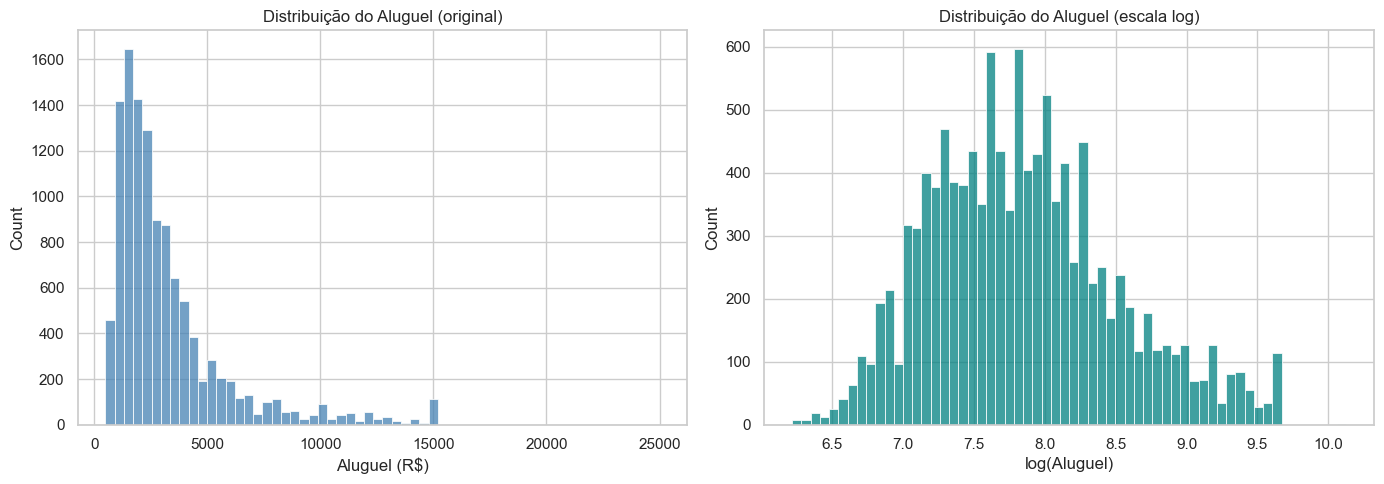

Mediana: R$ 2,415
Média:   R$ 3,251


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição original
sns.histplot(df['rent'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição do Aluguel (original)')
axes[0].set_xlabel('Aluguel (R$)')

# Distribuição em log (remove assimetria)
sns.histplot(np.log1p(df['rent']), bins=60, ax=axes[1], color='teal')
axes[1].set_title('Distribuição do Aluguel (escala log)')
axes[1].set_xlabel('log(Aluguel)')

plt.tight_layout()
plt.savefig('../data/dist_preco.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mediana: R$ {df["rent"].median():,.0f}')
print(f'Média:   R$ {df["rent"].mean():,.0f}')

## 5. Preço médio por bairro (Top 20)

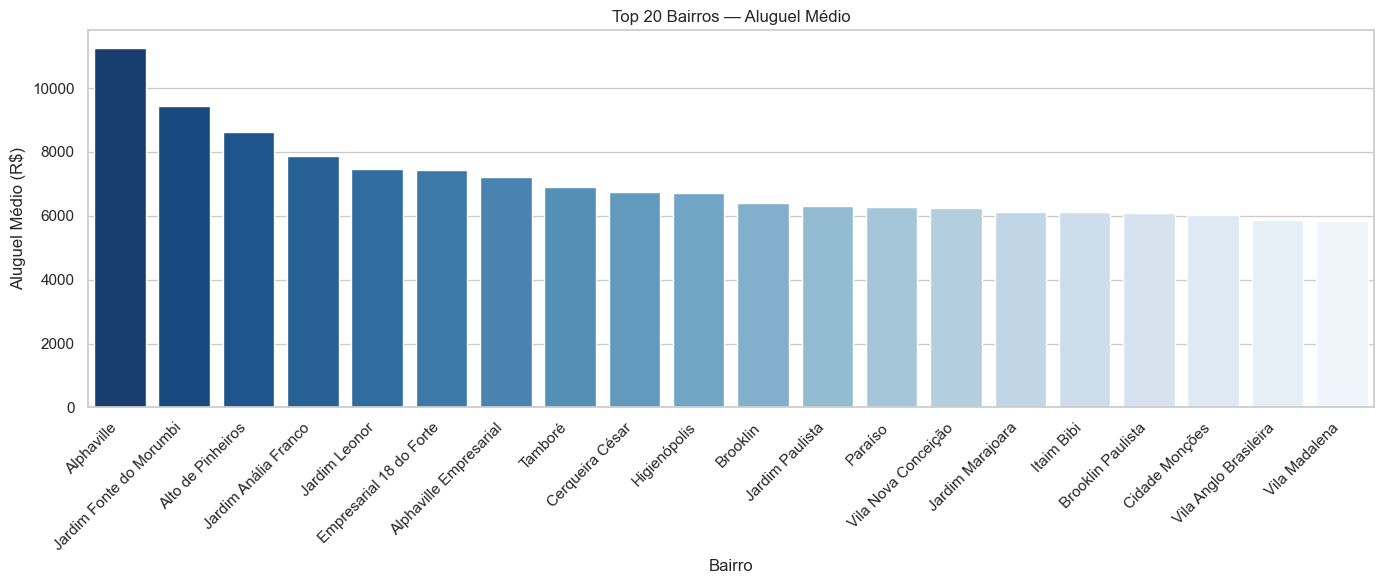

In [6]:
preco_bairro = (
    df.groupby('district')['rent']
    .agg(['mean', 'count'])
    .query('count >= 10')
    .sort_values('mean', ascending=False)
    .head(20)
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(data=preco_bairro, x='district', y='mean', palette='Blues_r')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Bairros — Aluguel Médio')
plt.xlabel('Bairro')
plt.ylabel('Aluguel Médio (R$)')
plt.tight_layout()
plt.savefig('../data/preco_bairro.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlação entre variáveis numéricas

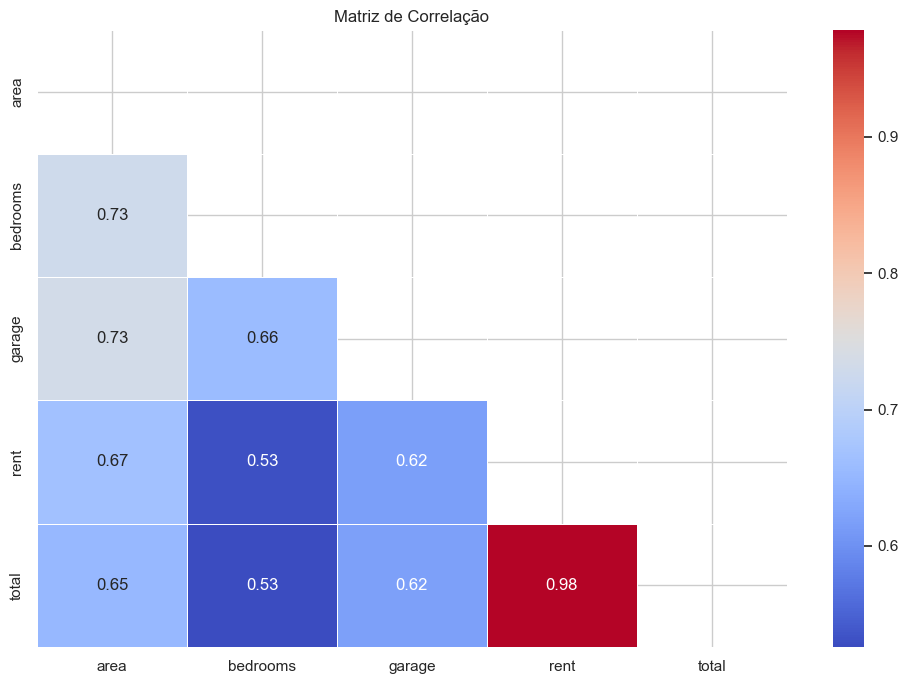

In [7]:
numericas = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(numericas.corr(), dtype=bool))
sns.heatmap(
    numericas.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5
)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.savefig('../data/correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Relação área x preço

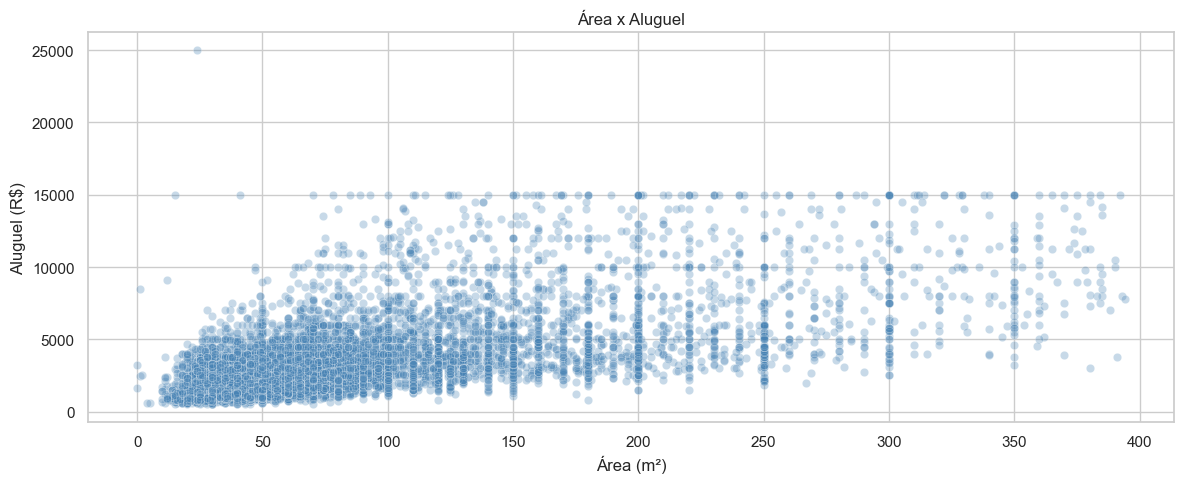

In [8]:
col_area = 'area'

# Remove outliers extremos para visualização
q99 = df[col_area].quantile(0.99)
df_plot = df[df[col_area] <= q99]

plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_plot, x=col_area, y='rent', alpha=0.3, color='steelblue')
plt.title('Área x Aluguel')
plt.xlabel('Área (m²)')
plt.ylabel('Aluguel (R$)')
plt.tight_layout()
plt.savefig('../data/area_preco.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Limpeza e tratamento dos dados

In [9]:
df_clean = df.copy()

# Remove duplicatas
antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicatas removidas: {antes - len(df_clean)}')

# Remove aluguéis zerados ou negativos
df_clean = df_clean[df_clean['rent'] > 0]

# Remove outliers extremos de aluguel (percentil 1 e 99)
p01 = df_clean['rent'].quantile(0.01)
p99 = df_clean['rent'].quantile(0.99)
df_clean = df_clean[(df_clean['rent'] >= p01) & (df_clean['rent'] <= p99)]

# Preenche nulos numéricos com mediana
for col in df_clean.select_dtypes(include=np.number).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f'  → {col}: preenchido com mediana')

# Preenche nulos categóricos com moda
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
        print(f'  → {col}: preenchido com moda')

print(f'\nShape original:  {df.shape}')
print(f'Shape limpo:     {df_clean.shape}')
print(f'Registros removidos: {len(df) - len(df_clean)}')

Duplicatas removidas: 0

Shape original:  (11657, 8)
Shape limpo:     (11425, 8)
Registros removidos: 232


## 9. Salvando o dataset limpo

In [11]:
df_clean.to_csv('../data/imoveis_clean.csv', index=False)
print('Dataset limpo salvo em: data/imoveis_clean.csv')
print(f'Total de registros prontos para modelagem: {len(df_clean):,}')

Dataset limpo salvo em: data/imoveis_clean.csv
Total de registros prontos para modelagem: 11,425
